In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
orders = pd.read_csv("orders.csv")

In [3]:
deliveries.columns

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

In [4]:
deliveries.isnull().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,19
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [5]:
deliveries.isnull().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,19
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [6]:
deliveries = deliveries.dropna()

In [7]:
status_summary = deliveries.groupby(
'delivery_status'
).size()

print(status_summary)

delivery_status
Delayed    193
Failed     128
OnTime     596
dtype: int64


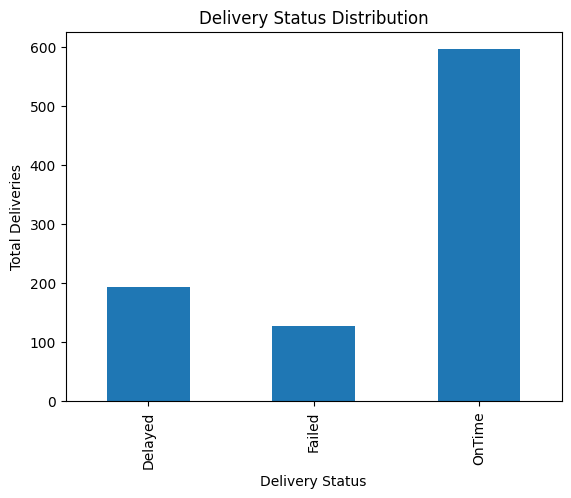

In [8]:
status_summary.plot(
kind='bar'
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Total Deliveries")
plt.show()

In [9]:
override_summary = deliveries.groupby(
'driver_id'
)['manual_route_override_count'].sum()

print(override_summary)

driver_id
D001    4
D002    7
D003    7
D004    7
D005    5
       ..
D166    7
D167    1
D168    5
D169    3
D170    5
Name: manual_route_override_count, Length: 170, dtype: int64


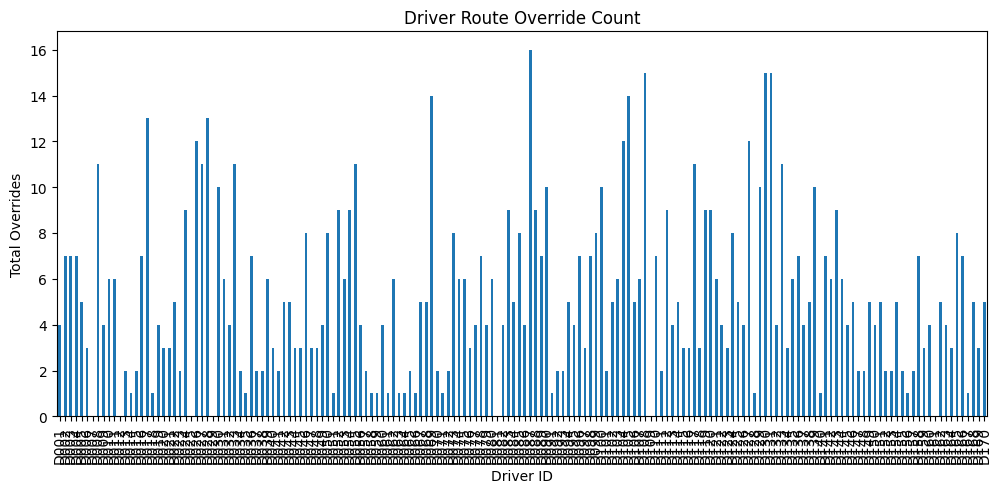

In [10]:
override_summary.plot(
kind='bar',
figsize=(12,5)
)

plt.title("Driver Route Override Count")
plt.xlabel("Driver ID")
plt.ylabel("Total Overrides")
plt.show()

In [11]:
rating_summary = deliveries.groupby(
'delivery_status'
)['customer_rating_post_delivery'].mean()

print(rating_summary)

delivery_status
Delayed    3.120259
Failed     3.056953
OnTime     4.286174
Name: customer_rating_post_delivery, dtype: float64


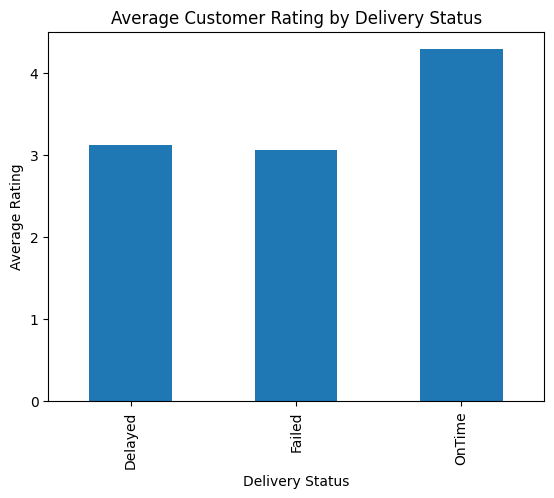

In [12]:
rating_summary.plot(
kind='bar'
)

plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Rating")
plt.show()

In [13]:
distance_summary = deliveries.groupby(
'hub_id'
)['route_distance_km'].mean()

print(distance_summary)

hub_id
H01    13.644924
H02    14.144118
H03    14.334211
H04    13.223089
H05    14.329732
H06    14.630505
H07    14.187411
H08    12.961951
Name: route_distance_km, dtype: float64


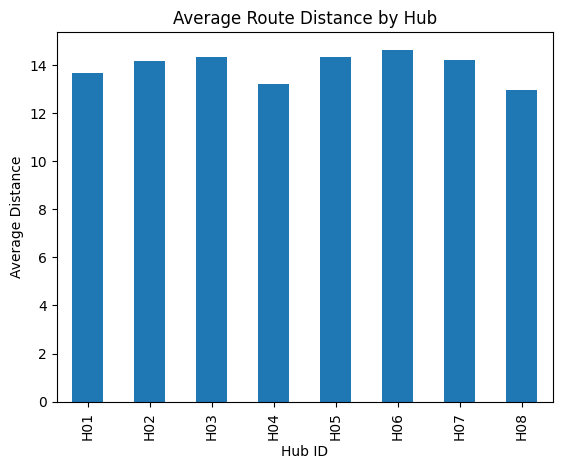

In [14]:
distance_summary.plot(
kind='bar'
)

plt.title("Average Route Distance by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Average Distance")
plt.show()

In [15]:
fuel_summary = deliveries.groupby(
'hub_id'
)['fuel_or_charge_cost'].mean()

print(fuel_summary)

hub_id
H01    12.752955
H02    12.511667
H03    12.657632
H04    13.196748
H05    13.627232
H06    13.409394
H07    12.992946
H08    11.732683
Name: fuel_or_charge_cost, dtype: float64


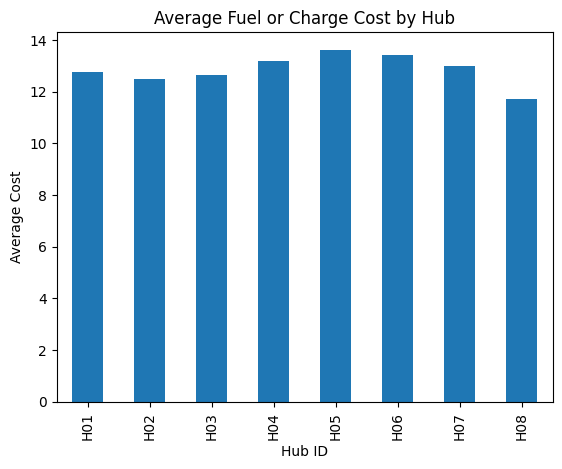

In [16]:
fuel_summary.plot(
kind='bar'
)

plt.title("Average Fuel or Charge Cost by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Average Cost")
plt.show()

In [17]:
proof_summary = deliveries.groupby(
'proof_of_completion_missing'
).size()

print(proof_summary)

proof_of_completion_missing
0    851
1     66
dtype: int64


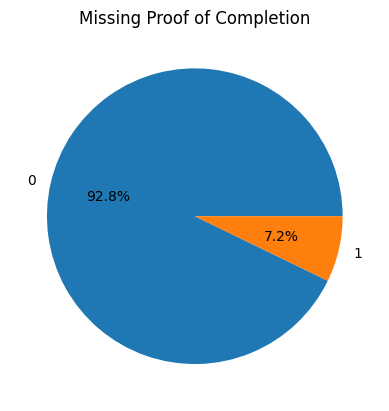

In [18]:
proof_summary.plot(
kind='pie',
autopct='%1.1f%%'
)

plt.title("Missing Proof of Completion")
plt.ylabel("")
plt.show()